In [1]:
from utils import load_and_prepare_data, benchmark_cpu, plot_latency_vs_f1_branchynet
from neural_network import *
from dense_branchynet import *
import time
from sklearn.metrics import classification_report
import os

numerical_cols = [
        "duration",
        "dst_bytes",
        "missed_bytes",
        "src_bytes",
        "src_ip_bytes",
        "src_pkts",
        "dst_pkts",
        "dst_ip_bytes",
        "http_request_body_len",
        "http_response_body_len"

    ]

categorical_cols = [
        "proto",
        "conn_state",
        "http_status_code",
        "http_method",
        "http_orig_mime_types",
        "http_resp_mime_types",
    ]


target_col = 'type'
num_target_classes = 6
dataset_path = 'datasets/http_ton.csv'
batch_size = 4096
epochs = 10
values_to_remove = {'type': ['mitm', 'dos']}

In [2]:
train_dataloader, valid_dataloader, test_dataloader, cat_cardinalities, cw, target_names = load_and_prepare_data(
    file_path=dataset_path,
    target_col=target_col,
    numerical_cols=numerical_cols,
    categorical_cols=categorical_cols,
    batch_size=batch_size,
    rows_to_remove=values_to_remove,
    test_batch_size = 1
)


embedding_dims = [min(50, (card + 1) // 2) for card in cat_cardinalities]

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNetwork.load('best_model.pt', device=device)
branchynet = DenseBranchyNet.load('branchynet.pth', device=device)
y_true = torch.cat([y for _, _, y in test_dataloader]).numpy()

[WARNING] CUDA non disponibile. Caricamento su CPU.
Modello DenseBranchyNet caricato da 'branchynet.pth'.


Starting margin for 0.88
Starting softmax + entropy for 0.88
--------------------------------
Starting margin for 0.89
Starting softmax + entropy for 0.89
--------------------------------
Starting margin for 0.9
Starting softmax + entropy for 0.9
--------------------------------
Starting margin for 0.91
Starting softmax + entropy for 0.91
--------------------------------
Starting margin for 0.92
Starting softmax + entropy for 0.92
--------------------------------
Starting margin for 0.93
Starting softmax + entropy for 0.93
--------------------------------
Starting margin for 0.94
Starting softmax + entropy for 0.94
--------------------------------
Starting margin for 0.95
Starting softmax + entropy for 0.95
--------------------------------
Starting margin for 0.96
Starting softmax + entropy for 0.96
--------------------------------
Starting margin for 0.97
Starting softmax + entropy for 0.97
--------------------------------
Starting margin for 0.98
Starting softmax + entropy for 0.98
-

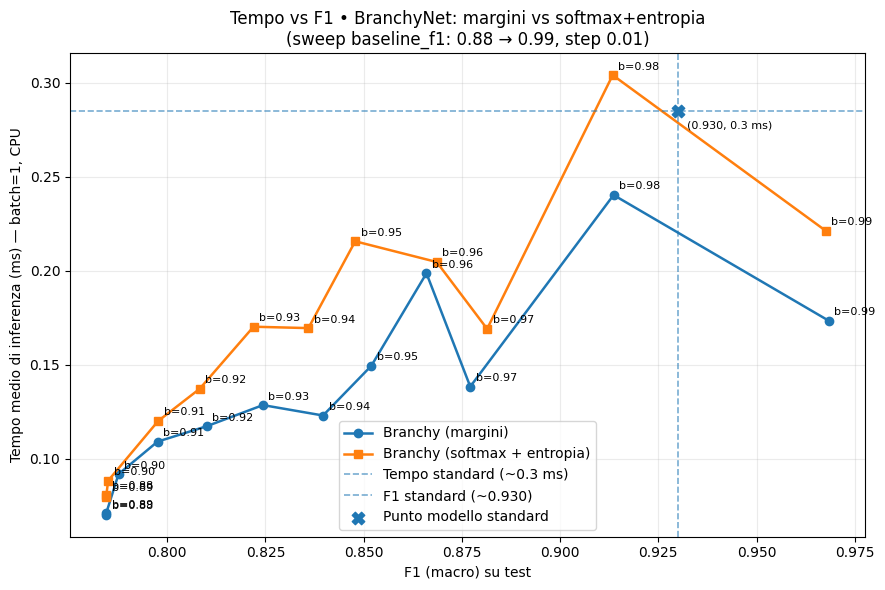

{'standard': {'f1': 0.9300782727047795, 'mean_ms': 0.2848248332485402},
 'margin': {'points': [(0.7844482825428095, 0.07013521347798513, 0.88),
   (0.7844482825428095, 0.0708620291702781, 0.89),
   (0.7876025646273636, 0.09176881756294172, 0.9),
   (0.7975292976406937, 0.1090486101996275, 0.91),
   (0.8100268224956614, 0.11723951919543717, 0.92),
   (0.8243537988069503, 0.1284972818748796, 0.93),
   (0.8396489276232981, 0.12295124812241813, 0.94),
   (0.8519398500488525, 0.1493927428685063, 0.95),
   (0.8659794343846644, 0.19864540759900443, 0.96),
   (0.8771273169284534, 0.1383404210465051, 0.97),
   (0.9136064463214035, 0.2403098229241308, 0.98),
   (0.9683799783192168, 0.17339087097040734, 0.99)]},
 'entropy': {'points': [(0.7844482825428095, 0.08070704397452415, 0.88),
   (0.7844482825428095, 0.0797993117565923, 0.89),
   (0.7849617101314555, 0.0882846648369621, 0.9),
   (0.7977041141240253, 0.12007208010114744, 0.91),
   (0.8082148135105321, 0.13709910795447375, 0.92),
   (0.82195

In [4]:
plot_latency_vs_f1_branchynet(
    model, branchynet,valid_dataloader,
    test_dataloader, y_true, device,
    f1_average='macro',
    num_threads=max(1, os.cpu_count()//2))